---
title: "Projection & orthogonalization"
categories: []
---


Projection is the geometric engine behind most of what remains in the course. Least-squares fitting (Chapter 8) *is* projection onto a column space; the two factors $\mathbf A\mathbf A^+$ and $\mathbf A^+\mathbf A$ of the pseudoinverse (Chapter 6) are projectors. This chapter develops orthogonal projection from first principles, then turns to the computational question it raises: how to build an orthonormal basis for a subspace (Gram-Schmidt, QR) and how to exploit one.


## Orthogonal projection: definition and uniqueness

Let $S \subseteq \mathbb R^m$ be a subspace and $\mathbf y \in \mathbb R^m$ an arbitrary vector. The [orthogonal projection]{.mark} of $\mathbf y$ onto $S$ is the vector $\hat{\mathbf y}\in S$ that makes the residual $\mathbf y-\hat{\mathbf y}$ orthogonal to *every* vector of $S$, written $\mathbf y-\hat{\mathbf y}\perp S$.

Two things are not obvious and must be checked: that such a vector is unique, and that it is the *closest* point of $S$ to $\mathbf y$. Uniqueness is a one-liner. If $\hat{\mathbf y}_1,\hat{\mathbf y}_2$ both satisfy the definition, then their difference is

$$\hat{\mathbf y}_1-\hat{\mathbf y}_2 \;\in\; S \qquad\text{and}\qquad \hat{\mathbf y}_1-\hat{\mathbf y}_2 = (\mathbf y-\hat{\mathbf y}_2)-(\mathbf y-\hat{\mathbf y}_1) \;\perp\; S .$$

A vector that lies both in $S$ and in its orthogonal complement must be zero, so $\hat{\mathbf y}_1=\hat{\mathbf y}_2$.

Closeness follows from the Pythagorean identity. For any $\mathbf s\in S$, write $\mathbf y-\mathbf s = (\mathbf y-\hat{\mathbf y}) + (\hat{\mathbf y}-\mathbf s)$. The two terms are orthogonal because $\mathbf y-\hat{\mathbf y}\perp S$ while $\hat{\mathbf y}-\mathbf s\in S$, hence

$$\lVert\mathbf y-\mathbf s\rVert^2 = \lVert\mathbf y-\hat{\mathbf y}\rVert^2 + \lVert\hat{\mathbf y}-\mathbf s\rVert^2 \;\ge\; \lVert\mathbf y-\hat{\mathbf y}\rVert^2 .$$

So $\hat{\mathbf y}$ is the nearest point of $S$ to $\mathbf y$, and equality holds only at $\mathbf s=\hat{\mathbf y}$. Projection and best approximation are the same operation.


## Projection via the SVD

Uniqueness settled, existence comes from the singular value decomposition. Let $\mathbf A\in\mathbb R^{m\times n}$ have SVD $\mathbf A = \mathbf U\boldsymbol\Sigma\mathbf V^{\mathsf T}$ with $\operatorname{rank}\mathbf A = r$. From Chapter 3, $\{\mathbf u_1,\dots,\mathbf u_r\}$ is an orthonormal basis of $\mathsf C(\mathbf A)$; complete it to an orthonormal basis $\mathbf u_1,\dots,\mathbf u_m$ of $\mathbb R^m$. Decompose $\mathbf y$ against this basis:

$$\mathbf y = \underbrace{\sum_{i=1}^{r}\mathbf u_i\mathbf u_i^{\mathsf T}\mathbf y}_{\in\,\mathsf C(\mathbf A)} + \underbrace{\sum_{i=r+1}^{m}\mathbf u_i\mathbf u_i^{\mathsf T}\mathbf y}_{\perp\,\mathsf C(\mathbf A)} .$$

The first sum lands in $\mathsf C(\mathbf A)$; the second is orthogonal to it, since each $\mathbf u_i$ with $i>r$ is orthogonal to every $\mathbf u_j$ with $j\le r$. This split is exactly the projection definition, so

$$\hat{\mathbf y} = \sum_{i=1}^{r}\mathbf u_i\mathbf u_i^{\mathsf T}\mathbf y = \mathbf U_r\mathbf U_r^{\mathsf T}\mathbf y .$$

But $\mathbf U_r\mathbf U_r^{\mathsf T} = \mathbf A\mathbf A^+$ by the pseudoinverse identity $\mathbf A\mathbf A^+ = \mathbf U\boldsymbol\Sigma\boldsymbol\Sigma^+\mathbf U^{\mathsf T} = \mathbf U_r\mathbf U_r^{\mathsf T}$ from Chapter 6. The projector onto the column space is therefore

$$\boxed{\,P_{\mathbf A} = \mathbf A\mathbf A^+ = \mathbf U_r\mathbf U_r^{\mathsf T} = \sum_{i=1}^{r}\mathbf u_i\mathbf u_i^{\mathsf T}\,}$$

Projection onto $\mathsf C(\mathbf A)$ is the sum of the first $r$ rank-one outer products — the same pieces that assemble $\mathbf A$ itself.


## The projector matrix

The projector $P = P_{\mathbf A}$ has a short list of structural properties, each worth internalizing.

| Property | Statement | Meaning |
|---|---|---|
| **Idempotent** | $P^2 = P$ | projecting twice equals projecting once |
| **Symmetric** | $P^{\mathsf T} = P$ | the projector is an *orthogonal* projector |
| **Spectrum** | eigenvalues in $\{0,1\}$ | $P\mathbf v=\mathbf v$ on $\mathsf C(\mathbf A)$, $P\mathbf v=\mathbf 0$ on $\mathsf C(\mathbf A)^{\perp}$ |
| **Complement** | $\mathbf I - P$ projects onto $\mathsf C(\mathbf A)^{\perp}=\mathsf N(\mathbf A^{\mathsf T})$ | the orthogonal split $\mathbf y = P\mathbf y + (\mathbf I-P)\mathbf y$ |

The complement is the four-subspace split of Chapter 4 in action: $P$ is the identity on the column space and annihilates the left null space, and every $\mathbf y$ splits uniquely into the two pieces. Idempotence alone forces the eigenvalues into $\{0,1\}$: if $P\mathbf v = \lambda\mathbf v$ then $\lambda\mathbf v = P\mathbf v = P^2\mathbf v = \lambda^2\mathbf v$, so $\lambda = \lambda^2$. Symmetry adds that the two eigenspaces are orthogonal — exactly the orthogonality of the projection.

When the columns of $\mathbf A$ are independent, $\mathbf A^{\mathsf T}\mathbf A$ is invertible and the projector takes the familiar form $P = \mathbf A(\mathbf A^{\mathsf T}\mathbf A)^{-1}\mathbf A^{\mathsf T}$, with unique weights $\mathbf x = (\mathbf A^{\mathsf T}\mathbf A)^{-1}\mathbf A^{\mathsf T}\mathbf y$. When they are dependent, the weights are not unique, but the projection still is.

In the one-dimensional case $S = \operatorname{span}\{\mathbf a\}$, the formula reduces to a clean geometric statement:

$$P_{\mathbf a}\,\mathbf y = \mathbf a(\mathbf a^{\mathsf T}\mathbf a)^{-1}\mathbf a^{\mathsf T}\mathbf y = \lVert\mathbf y\rVert\cos\theta\;\hat{\mathbf a},$$

where $\theta$ is the angle between $\mathbf a$ and $\mathbf y$ and $\hat{\mathbf a}$ is the unit vector along $\mathbf a$. The projection is the component of $\mathbf y$ in the direction of $\mathbf a$.


**Projecting onto a plane.** The figure below projects a test vector $\mathbf b$ onto the column space of a random $3\times 2$ matrix (a plane through the origin) and verifies that the residual is perpendicular to the plane.


In [1]:
from watchtower.core import set_format
set_format("svg")


(Ax - b) . Ax = 1.5178830414797062e-17


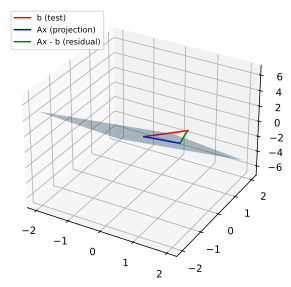

In [2]:
#| label: fig-projection-3d
#| cap: "**Projection onto a plane.** The test vector $\\mathbf{b}$ (red), its projection $\\mathbf{A}\\mathbf{x}$ onto $\\mathrm{C}(\\mathbf{A})$ (blue), and the residual $\\mathbf{A}\\mathbf{x}-\\mathbf{b}$ (green), which is orthogonal to the plane."
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(18)
A = np.random.randn(3, 2)
c = np.cross(A[:, 0], A[:, 1])      # normal to the plane C(A)   # <1>
b = np.array([0.9, 0.8, 0.2])       # test vector

x = np.linalg.solve(A.T @ A, A.T @ b)   # weights via normal equations  # <2>
Ax = A @ x                           # the projection

fig = plt.figure(figsize=plt.figaspect(1))
ax = fig.add_subplot(projection='3d')
xx, yy = np.meshgrid(np.linspace(-2, 2), np.linspace(-2, 2))
z = -(c[0] * xx + c[1] * yy) / c[2]
ax.plot_surface(xx, yy, z, alpha=0.4)
ax.plot([0, b[0]], [0, b[1]], [0, b[2]], 'r', label='b (test)')
ax.plot([0, Ax[0]], [0, Ax[1]], [0, Ax[2]], 'b', label='Ax (projection)')
ax.plot([Ax[0], b[0]], [Ax[1], b[1]], [Ax[2], b[2]], 'g', label='Ax - b (residual)')
ax.legend(loc='upper left', fontsize=8)
print('(Ax - b) . Ax =', (Ax - b) @ Ax)
plt.show()


<1> The normal vector $c$ is the cross product of the two columns, which defines the plane as $\{\mathbf z : \mathbf z^{\mathsf T}c = 0\}$; the surface is plotted from that equation.

<2> The weights solve the normal equations $\mathbf A^{\mathsf T}\mathbf A\mathbf x = \mathbf A^{\mathsf T}\mathbf b$, which is exactly $\mathbf A^{\mathsf T}(\mathbf b-\mathbf A\mathbf x)=\mathbf 0$ — the residual is orthogonal to both columns of $\mathbf A$, hence to the whole plane. The printed dot product confirms it is numerically zero.


## Orthonormal columns

The factor $(\mathbf A^{\mathsf T}\mathbf A)^{-1}$ in $P = \mathbf A(\mathbf A^{\mathsf T}\mathbf A)^{-1}\mathbf A^{\mathsf T}$ exists only to correct for redundancy among the columns. When the columns are already orthonormal, $\mathbf U^{\mathsf T}\mathbf U = \mathbf I_n$, the correction is the identity, and the projector simplifies to

$$\boxed{\,P_{\mathbf U} = \mathbf U\mathbf U^{\mathsf T} = \sum_{j=1}^{n}\mathbf u_j\mathbf u_j^{\mathsf T}\,}$$

Projecting onto orthonormal directions is *additive*: project onto each $\mathbf u_j$ independently and sum, with no cross-talk to remove. This is the payoff of orthonormal bases, and it motivates the next question — how to produce one from arbitrary columns.


## The Gram-Schmidt process

Given columns $\mathbf a_1,\dots,\mathbf a_n$ spanning a subspace, the [Gram-Schmidt process]{.mark} builds an orthonormal basis $\mathbf q_1,\dots,\mathbf q_r$ of that span one vector at a time. It is the constructive form of the projection theory above: to make $\mathbf a_k$ orthogonal to everything already built, subtract its projection onto the span of the earlier vectors, then normalize.

1. $\mathbf q_1 = \mathbf a_1/\lVert\mathbf a_1\rVert$.
2. $\mathbf q_k = \dfrac{\mathbf a_k - \sum_{j=1}^{k-1}\mathbf q_j\mathbf q_j^{\mathsf T}\mathbf a_k}{\left\lVert\mathbf a_k - \sum_{j=1}^{k-1}\mathbf q_j\mathbf q_j^{\mathsf T}\mathbf a_k\right\rVert}$, for $k=2,\dots,n$.

The numerator $\mathbf a_k - \sum_{j<k}\mathbf q_j\mathbf q_j^{\mathsf T}\mathbf a_k$ is $\mathbf a_k$ with its components along $\mathbf q_1,\dots,\mathbf q_{k-1}$ removed, so it is orthogonal to each of them; normalization then makes it a unit vector. Any column that ends up in the span of earlier columns produces a zero numerator and is discarded, which is how the process lands on exactly $r$ vectors.


## Modified Gram-Schmidt and numerical stability

Classical Gram-Schmidt has a subtle floating-point flaw. Step 2 computes every inner product $\mathbf q_j^{\mathsf T}\mathbf a_k$ against the *original* $\mathbf a_k$, accumulating a sum of projections all at once. The [modified Gram-Schmidt]{.mark} variant instead updates a working copy of $\mathbf a_k$ in place, projecting away each $\mathbf q_j$ component as soon as $\mathbf q_j$ is formed:

1. Copy $\mathbf v_k = \mathbf a_k$ for all $k$.
2. For $k=1,\dots,n$: set $\mathbf q_k = \mathbf v_k/\lVert\mathbf v_k\rVert$, then for $j>k$ set $\mathbf v_j \leftarrow \mathbf v_j - \mathbf q_k\mathbf q_k^{\mathsf T}\mathbf v_j$.

In exact arithmetic the two are identical. In floating point they are not, and the difference is largest exactly when it matters most: columns that are nearly parallel. The next cell sweeps a parameter $\varepsilon$ over many decades and measures how far the computed $\mathbf Q$ is from orthonormal.


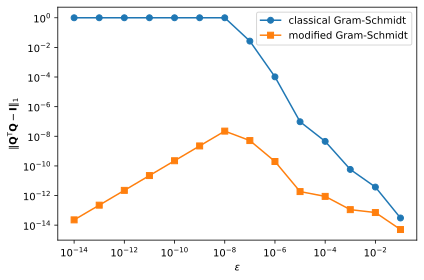

In [3]:
#| label: fig-gs-stability
#| cap: "**Numerical stability of Gram-Schmidt.** Orthonormality error $\\lVert\\mathbf{Q}^{\\mathsf{T}}\\mathbf{Q}-\\mathbf{I}\\rVert_1$ versus $\\varepsilon$ for classical (circles) and modified (squares) Gram-Schmidt on the matrix with columns $(1,\\varepsilon,0,0)$, $(1,0,\\varepsilon,0)$, $(1,0,0,\\varepsilon)$."
import numpy as np
import matplotlib.pyplot as plt

def cgs(A):
    U = np.zeros_like(A)
    U[:, 0] = A[:, 0] / np.linalg.norm(A[:, 0])
    for k in range(1, A.shape[1]):
        u = A[:, k] - U[:, :k] @ (U[:, :k].T @ A[:, k])   # project against originals
        U[:, k] = u / np.linalg.norm(u)
    return U

def mgs(A):
    U = np.copy(A)
    for k in range(A.shape[1]):
        U[:, k] = U[:, k] / np.linalg.norm(U[:, k])
        for j in range(k + 1, A.shape[1]):
            U[:, j] = U[:, j] - U[:, k] * (U[:, k].T @ U[:, j])   # update in place
    return U

epsilons = np.logspace(-14, -1, 14)
err_cgs, err_mgs = [], []
for eps in epsilons:
    A = np.array([[1, 1, 1], [eps, 0, 0], [0, eps, 0], [0, 0, eps]], dtype=float)
    n = A.shape[1]
    err_cgs.append(np.abs((cgs(A).T @ cgs(A)) - np.eye(n)).sum())
    err_mgs.append(np.abs((mgs(A).T @ mgs(A)) - np.eye(n)).sum())

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(epsilons, err_cgs, 'o-', label='classical Gram-Schmidt')
ax.loglog(epsilons, err_mgs, 's-', label='modified Gram-Schmidt')
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel(r'$\|\mathbf{Q}^{\mathsf{T}}\mathbf{Q}-\mathbf{I}\|_1$')
ax.legend()
fig.tight_layout()
plt.show()


The classical variant loses orthogonality like $u\kappa^2 \sim 1/\varepsilon^2$ until it saturates at $O(1)$ once $\varepsilon \lesssim \sqrt{u} \approx 10^{-8}$ — at the smallest $\varepsilon$ the error is total. The mechanism is visible in the third column: classical Gram-Schmidt forms $r_{23} = \mathbf q_2^{\mathsf T}\mathbf a_3$ against the *original* column, before the inexact $\mathbf q_1$-update has introduced a $\mathbf q_2$-component of size $\varepsilon/\sqrt 2$ into the residual, so the subtraction $\mathbf a_3 - \mathbf q_1(\mathbf q_1^{\mathsf T}\mathbf a_3) - \mathbf q_2 r_{23}$ misses it. Modified Gram-Schmidt avoids this because each inner product is formed against the *current* residual — the $\mathbf q_2$-component is removed from $\mathbf a_3$ before the $r_{23}$ coefficient is computed — so its error stays at $O(\varepsilon)$.


## The QR decomposition

Gram-Schmidt is more than an algorithm for producing orthonormal bases; it is a *factorization*. At step $k$ the recurrence is $\mathbf a_k = \lVert\mathbf v_k\rVert\,\mathbf q_k + \sum_{j<k}(\mathbf q_j^{\mathsf T}\mathbf a_k)\mathbf q_j$, so each $\mathbf a_k$ is a combination of $\mathbf q_1,\dots,\mathbf q_k$ only. Stacking these relations for $k=1,\dots,n$ gives

$$\mathbf A = \mathbf Q\mathbf R,$$

where $\mathbf Q$ has orthonormal columns and $\mathbf R$ is upper triangular with $r_{jk} = \mathbf q_j^{\mathsf T}\mathbf a_k$ for $j\le k$ (and $r_{jk}=0$ for $j>k$). The [QR decomposition]{.mark} of a full-rank matrix is unique up to signs of the diagonal of $\mathbf R$. NumPy computes it with Householder reflections rather than Gram-Schmidt, which keeps the orthonormality at machine precision regardless of the conditioning.


In [4]:
A = np.random.randn(20, 20)
Q, R = np.linalg.qr(A)
print('A - QR residual          :', np.abs(A - Q @ R).max())
print('Q^T Q - I (orthonormal)  :', np.abs(Q.T @ Q - np.eye(20)).max())
print('R is upper triangular    :', np.allclose(R, np.triu(R)))


A - QR residual          : 3.774758283725532e-15
Q^T Q - I (orthonormal)  : 1.1102230246251565e-15
R is upper triangular    : True


The residual $\lVert\mathbf A-\mathbf Q\mathbf R\rVert$ is at machine precision and $\mathbf Q^{\mathsf T}\mathbf Q$ is exactly the identity to within roundoff — the two guarantees a QR factorization must deliver. Every entry strictly below the diagonal of $\mathbf R$ is zero, confirming the upper-triangular structure.


## Solving and inverting with QR

For a square invertible $\mathbf A$, the QR decomposition gives the inverse almost for free:

$$\boxed{\,\mathbf A^{-1} = \mathbf R^{-1}\mathbf Q^{\mathsf T}\,}$$

The gain is that a single system $\mathbf A\mathbf x = \mathbf b$ costs $O(n^2)$ once the factorization is known: solve $\mathbf R\mathbf x = \mathbf Q^{\mathsf T}\mathbf b$ by back substitution, instead of a general $O(n^3)$ elimination on $\mathbf A$. Forming $\mathbf R^{-1}$ explicitly is still an $O(n^3)$ operation (one back substitution per column), so the cheap path is to *solve*, never to invert. The next cell times both a general inverse and a triangular solve across sizes.


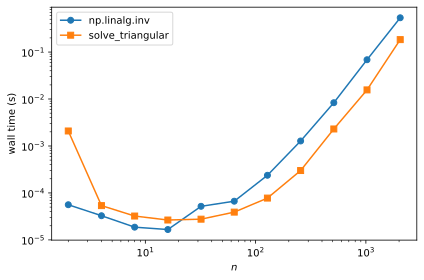

In [5]:
#| label: fig-qr-timing
#| cap: "**Triangular solves are fast.** Wall time for a general inverse versus a triangular solve as the matrix size $n$ doubles."
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

inv_times, tri_times = [], []
sizes = [2**j for j in range(1, 12)]
for n in sizes:
    A = np.random.randn(n, n)
    t0 = time.perf_counter(); np.linalg.inv(A); inv_times.append(time.perf_counter() - t0)
    T = np.triu(A)
    t0 = time.perf_counter(); solve_triangular(T, np.eye(n), lower=False); tri_times.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(sizes, inv_times, 'o-', label='np.linalg.inv')
ax.loglog(sizes, tri_times, 's-', label='solve_triangular')
ax.set_xlabel(r'$n$')
ax.set_ylabel('wall time (s)')
ax.legend()
fig.tight_layout()
plt.show()


Both curves are cubic in $n$, but the triangular solve sits a constant factor lower — the constant that back substitution saves by never touching the zero entries. For a single linear system the right operation is `solve`, not an inverse at all; QR matters when the *same* $\mathbf A$ is inverted against many right-hand sides, or when a triangular structure is handed to a solver that can exploit it.


## The Sherman-Morrison formula

A rank-one perturbation of the identity has an explicit inverse. First note $\det(\mathbf I + \mathbf u\mathbf v^{\mathsf T}) = 1 + \mathbf v^{\mathsf T}\mathbf u$: expanding $\det(\mathbf e_1 + v_1\mathbf u, \dots, \mathbf e_n + v_n\mathbf u)$ by multilinearity, the only nonzero terms are the identity term $1$ and the $n$ terms with exactly one column replaced by $\mathbf u$, each contributing $v_j u_j$ — terms with two or more $\mathbf u$'s repeat a column and vanish. So $\mathbf I+\mathbf u\mathbf v^{\mathsf T}$ is invertible precisely when $1+\mathbf v^{\mathsf T}\mathbf u\neq 0$. In that case

$$\boxed{\,\left(\mathbf I + \mathbf u\mathbf v^{\mathsf T}\right)^{-1} = \mathbf I - \frac{\mathbf u\mathbf v^{\mathsf T}}{1+\mathbf v^{\mathsf T}\mathbf u}\,}$$

The [Sherman-Morrison formula]{.mark} is verified by multiplying out: $(\mathbf I+\mathbf u\mathbf v^{\mathsf T})(\mathbf I - \frac{\mathbf u\mathbf v^{\mathsf T}}{1+\mathbf v^{\mathsf T}\mathbf u})$ telescopes to $\mathbf I$ because the cross terms $\mathbf u\mathbf v^{\mathsf T}\mathbf u\mathbf v^{\mathsf T} = (\mathbf v^{\mathsf T}\mathbf u)\,\mathbf u\mathbf v^{\mathsf T}$ collapse against the denominator.[^woodbury]

[^woodbury]: The [Woodbury identity](https://en.wikipedia.org/wiki/Woodbury_matrix_identity) generalizes this to a rank-$k$ update, $(\mathbf A+\mathbf U\mathbf C\mathbf V^{\mathsf T})^{-1}$, at the cost of inverting a $k\times k$ matrix. Sherman-Morrison is its $k=1$ case.


In [6]:
np.random.seed(1)
u = np.random.randn(5)
v = np.random.randn(5)
I = np.eye(5)
M = I + np.outer(u, v)
explicit = np.linalg.inv(M)
sherman = I - np.outer(u, v) / (1 + v @ u)
print('Sherman-Morrison residual:', np.abs(explicit - sherman).max())


Sherman-Morrison residual: 5.551115123125783e-16


The formula replaces an $O(n^3)$ inverse with $O(n^2)$ outer products. This is the workhorse of [quasi-Newton](https://en.wikipedia.org/wiki/Quasi-Newton_method) optimizers and of online linear solvers, where a solution is updated cheaply as new rank-one data arrives instead of being recomputed from scratch.


## Summary

Projection onto a subspace is the unique nearest-point map, and its matrix is the sum of rank-one outer products $P = \mathbf U_r\mathbf U_r^{\mathsf T} = \mathbf A\mathbf A^+$ supplied directly by the SVD. The projector is idempotent and symmetric, with eigenvalues in $\{0,1\}$ and complement $\mathbf I-P$ on the orthogonal subspace. Gram-Schmidt turns arbitrary columns into an orthonormal basis and simultaneously yields the QR factorization $\mathbf A=\mathbf Q\mathbf R$; its modified variant is numerically stable where the classical one is not. QR gives cheap triangular solves via back substitution, and the Sherman-Morrison formula gives closed-form inverses for rank-one updates of the identity.


## Problems

The problems below exercise the projection theory, the Gram-Schmidt process, and the Sherman-Morrison formula. Problems 1-2 are derivations, Problems 3-4 are numerical, and Problem 5 is a challenge experiment.


### Problem 1 — The projector and its complement

Let $S\subseteq\mathbb R^m$ be a subspace and $P$ the orthogonal projector onto $S$, so $P\mathbf y\in S$ and $\mathbf y-P\mathbf y\perp S$ for every $\mathbf y\in\mathbb R^m$.

(a) Show that $\mathbf I-P$ is the orthogonal projector onto $S^{\perp}$: it is symmetric, idempotent, and satisfies $(\mathbf I-P)\mathbf y\in S^{\perp}$ with $\mathbf y-(\mathbf I-P)\mathbf y\perp S^{\perp}$.

(b) Show that $\lVert\mathbf y\rVert^2=\lVert P\mathbf y\rVert^2+\lVert(\mathbf I-P)\mathbf y\rVert^2$ for every $\mathbf y$.

(c) Show that $\operatorname{tr}P=\dim S$. *Hint:* the projector table's eigenvalue argument gives the spectrum of $P$; the trace is the sum of the eigenvalues.


### Problem 2 — The closest point on a line

Let $\mathbf a,\mathbf y\in\mathbb R^m$ with $\mathbf a\neq\mathbf 0$, and let $S=\operatorname{span}\{\mathbf a\}$.

(a) Expand $\lVert\mathbf y-\alpha\mathbf a\rVert^2$ as a quadratic in $\alpha$ and minimize it by calculus. Show that the minimizer is $\alpha^*=\mathbf a^{\mathsf T}\mathbf y/\mathbf a^{\mathsf T}\mathbf a$ and that the squared distance from $\mathbf y$ to $S$ is

$$\lVert\mathbf y-\alpha^*\mathbf a\rVert^2=\lVert\mathbf y\rVert^2-\frac{(\mathbf a^{\mathsf T}\mathbf y)^2}{\mathbf a^{\mathsf T}\mathbf a}.$$

(b) Show that the minimizer satisfies the orthogonality condition $(\mathbf y-\alpha^*\mathbf a)^{\mathsf T}\mathbf a=0$, so $\alpha^*\mathbf a$ is exactly the orthogonal projection of $\mathbf y$ onto $S$.

(c) Let $\theta$ be the angle between $\mathbf a$ and $\mathbf y$. Show that $\alpha^*\lVert\mathbf a\rVert=\lVert\mathbf y\rVert\cos\theta$, recovering the one-dimensional projection formula $P_{\mathbf a}\mathbf y=\mathbf a(\mathbf a^{\mathsf T}\mathbf a)^{-1}\mathbf a^{\mathsf T}\mathbf y$ from the chapter.


### Problem 3 — Three routes to the projector

For a full-rank $\mathbf A\in\mathbb R^{m\times n}$ with $m>n$, the projector onto $\mathsf C(\mathbf A)$ can be built three ways: $P_1=\mathbf A(\mathbf A^{\mathsf T}\mathbf A)^{-1}\mathbf A^{\mathsf T}$ from the normal equations, $P_2=\mathbf Q\mathbf Q^{\mathsf T}$ from the QR decomposition, and $P_3=\mathbf U_r\mathbf U_r^{\mathsf T}$ from the SVD. The three formulas are algebraically identical; the task is to confirm that they agree in floating point.

(a) Compute $P_1,P_2,P_3$ for a random $8\times 3$ matrix and a test vector $\mathbf y$, and report the pairwise differences $\lVert P_i-P_j\rVert_1$ and the idempotence residual $\lVert P^2-P\rVert_1$.

(b) Verify the projection properties: the residual orthogonality $\lVert(\mathbf y-P\mathbf y)^{\mathsf T}\mathbf A\rVert_\infty$ and the Pythagorean identity $\lVert P\mathbf y\rVert^2+\lVert\mathbf y-P\mathbf y\rVert^2=\lVert\mathbf y\rVert^2$.

The starter code builds the data; fill in the three projectors and the checks.


In [1]:
import numpy as np

rng = np.random.default_rng(7)
m, n = 8, 3
A = rng.standard_normal((m, n))
y = rng.standard_normal(m)

# P1 = A @ np.linalg.inv(A.T @ A) @ A.T          # normal equations
# P2 = Q @ Q.T                                   # from np.linalg.qr(A)
# P3 = U[:, :n] @ U[:, :n].T                     # from np.linalg.svd(A, full_matrices=False)

# (a) pairwise differences max |P_i - P_j| and idempotence residual max |P @ P - P|
# (b) residual orthogonality max |(y - P @ y) @ A| and the Pythagorean identity


### Problem 4 — Gram-Schmidt in floating point

The chapter's stability demo compares classical and modified Gram-Schmidt on the matrix with columns $(1,\varepsilon,0,0)$, $(1,0,\varepsilon,0)$, $(1,0,0,\varepsilon)$. This problem repeats the comparison at the fixed value $\varepsilon=10^{-10}$ and adds the Householder QR from `np.linalg.qr` as a third contestant.

(a) Implement `cgs` and `mgs` as in the chapter, and compute the orthonormality error $\lVert\mathbf Q^{\mathsf T}\mathbf Q-\mathbf I\rVert_1$ for all three methods.

(b) Verify the factorization residual $\lVert\mathbf A-\mathbf Q\mathbf R\rVert_\infty$ is small for all three methods: Gram-Schmidt is backward stable even where it loses orthogonality.

The starter code provides the data and the two function stubs.


In [1]:
import numpy as np

def cgs(A):
    """Classical Gram-Schmidt: project each column against the originals."""
    ...

def mgs(A):
    """Modified Gram-Schmidt: update a working copy in place."""
    ...

eps = 1e-10
A = np.array([[1, 1, 1], [eps, 0, 0], [0, eps, 0], [0, 0, eps]], dtype=float)
n = A.shape[1]

# (a) orthonormality error ||Q^T Q - I||_1 for cgs, mgs, and np.linalg.qr
# (b) factorization residual ||A - Q R||_inf for each


### Problem 5 — Sherman-Morrison: verify, invert, and break

**Challenge.** The Sherman-Morrison formula gives $(\mathbf I+\mathbf u\mathbf v^{\mathsf T})^{-1}=\mathbf I-\mathbf u\mathbf v^{\mathsf T}/(1+\mathbf v^{\mathsf T}\mathbf u)$ whenever $1+\mathbf v^{\mathsf T}\mathbf u\neq 0$. This experiment verifies the formula, checks the determinant identity, and probes its behavior as the matrix approaches singularity.

(a) For $n\in\{4,16,64\}$, compare the formula against `np.linalg.inv` on random draws and report the relative error $\lVert M_{\text{inv}}^{-1}-M_{\text{sm}}^{-1}\rVert_\infty/\lVert M_{\text{inv}}^{-1}\rVert_\infty$. It should stay at machine precision.

(b) Verify the determinant identity $\det(\mathbf I+\mathbf u\mathbf v^{\mathsf T})=1+\mathbf v^{\mathsf T}\mathbf u$ numerically on the same draws.

(c) Approach singularity: fix $\mathbf u$, set $\mathbf v=-\mathbf u/(\mathbf u^{\mathsf T}\mathbf u)+\delta\mathbf w$ for $\delta\in\{10^{-2},10^{-7},10^{-12}\}$, so that $1+\mathbf v^{\mathsf T}\mathbf u=\delta\,\mathbf w^{\mathsf T}\mathbf u$ shrinks with $\delta$. The formula is exact algebraically, but the inverse itself becomes ill-conditioned with $\kappa(\mathbf I+\mathbf u\mathbf v^{\mathsf T})\approx 1/\delta$. Measure the relative error and the condition number as functions of $\delta$, and confirm that the error grows like $1/\delta$: the product of the error and $\delta$ stays roughly constant.

The starter code sets up the draws; fill in the measurements.


In [1]:
import numpy as np

rng = np.random.default_rng(11)

# (a) for n in [4, 16, 64]: draw u, v; M = I + outer(u, v);
#     relative error of I - outer(u, v) / (1 + v @ u) vs np.linalg.inv(M)
for n in [4, 16, 64]:
    u = rng.standard_normal(n)
    v = rng.standard_normal(n)
    M = np.eye(n) + np.outer(u, v)
    # rel_err = ...
    # print(n, rel_err)

# (b) determinant identity: np.linalg.det(M) vs 1 + v @ u

# (c) near-singular scaling
n = 8
u = rng.standard_normal(n)
w = rng.standard_normal(n)
for delta in [1e-2, 1e-7, 1e-12]:
    v = -u / (u @ u) + delta * w
    M = np.eye(n) + np.outer(u, v)
    # print(delta, 1 + v @ u, np.linalg.cond(M), rel_err)
